In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")



file_path = "/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv"

df = pd.read_csv(file_path)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [11]:
#basic data inspection---

print("Shape of dataset:", df.shape)
print("\nColumn Names:\n", df.columns)
print("\nData Types:\n")
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nStatistical Summary:\n")
df.describe()

Shape of dataset: (2640, 12)

Column Names:
 Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

Data Types:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null  

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [12]:
# creatin a date column --

df["Date"] = pd.to_datetime(df[["Year", "Month"]].assign(DAY=1))

df = df.sort_values("Date")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
872,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01
2354,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01
2312,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01
2293,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01
2215,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01


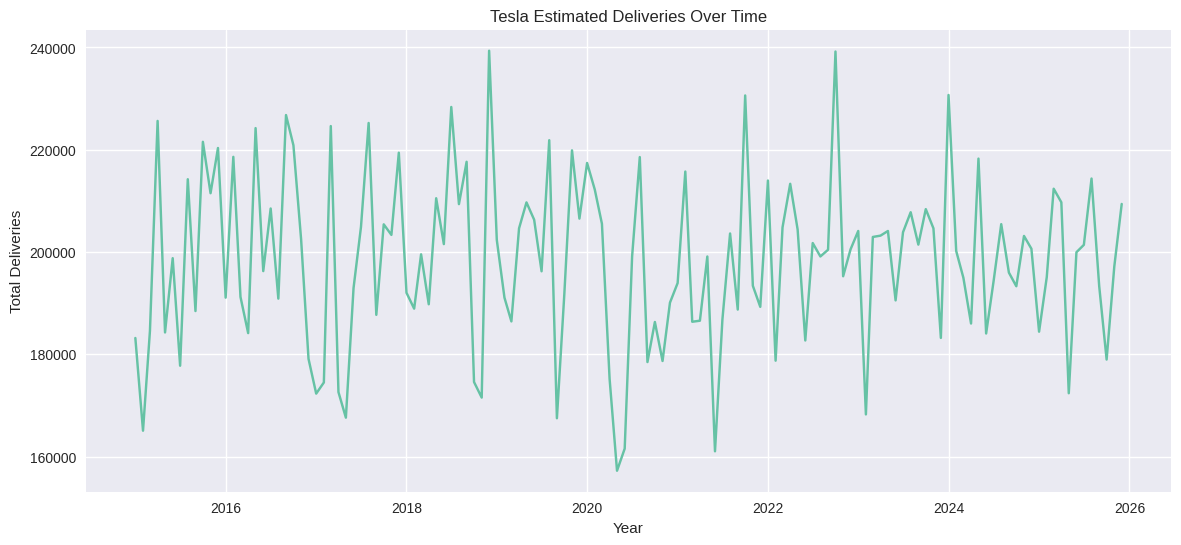

In [13]:
#Overall Deliveries Trend---

monthly_deliveries = df.groupby("Date")["Estimated_Deliveries"].sum()

plt.figure(figsize=(14,6))
plt.plot(monthly_deliveries)
plt.title("Tesla Estimated Deliveries Over Time")
plt.xlabel("Year")
plt.ylabel("Total Deliveries")
plt.show()

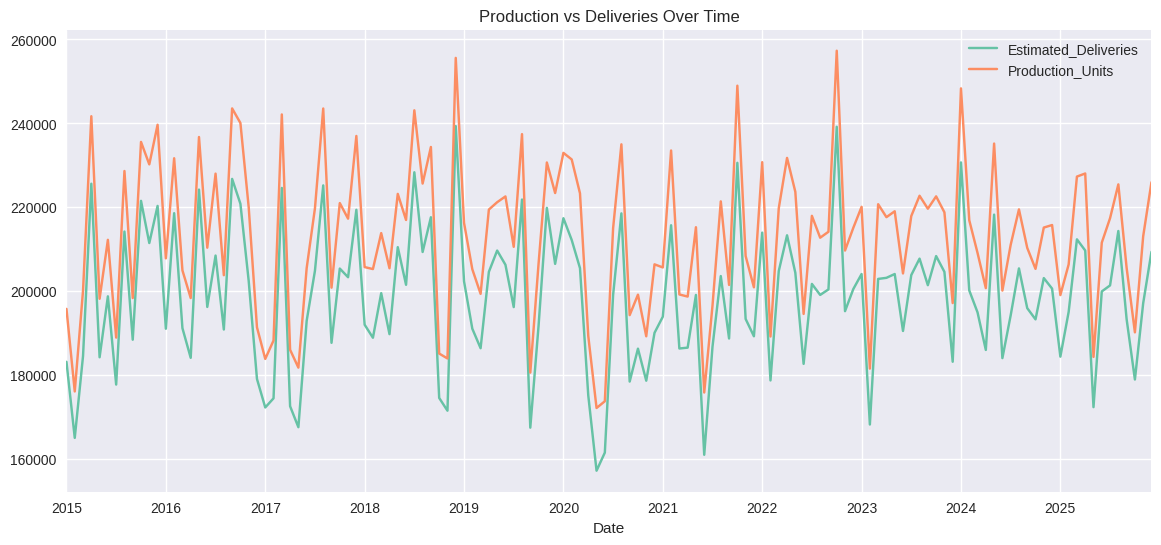

In [14]:
# Deliveries vs Production---

monthly_data = df.groupby("Date")[["Estimated_Deliveries", "Production_Units"]].sum()

monthly_data.plot(figsize=(14,6))
plt.title("Production vs Deliveries Over Time")
plt.show()

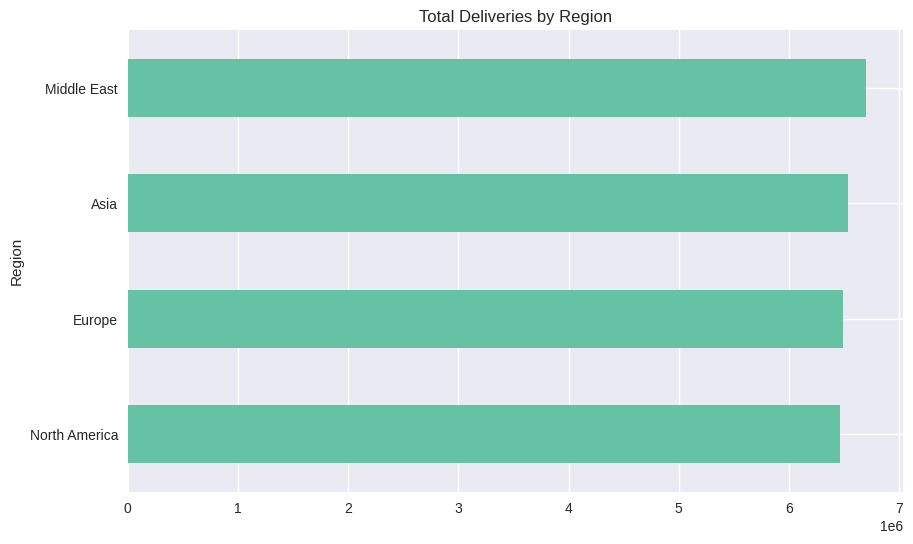

In [15]:
# Deliveries by Region----

region_data = df.groupby("Region")["Estimated_Deliveries"].sum().sort_values()

plt.figure(figsize=(10,6))
region_data.plot(kind="barh")
plt.title("Total Deliveries by Region")
plt.show()

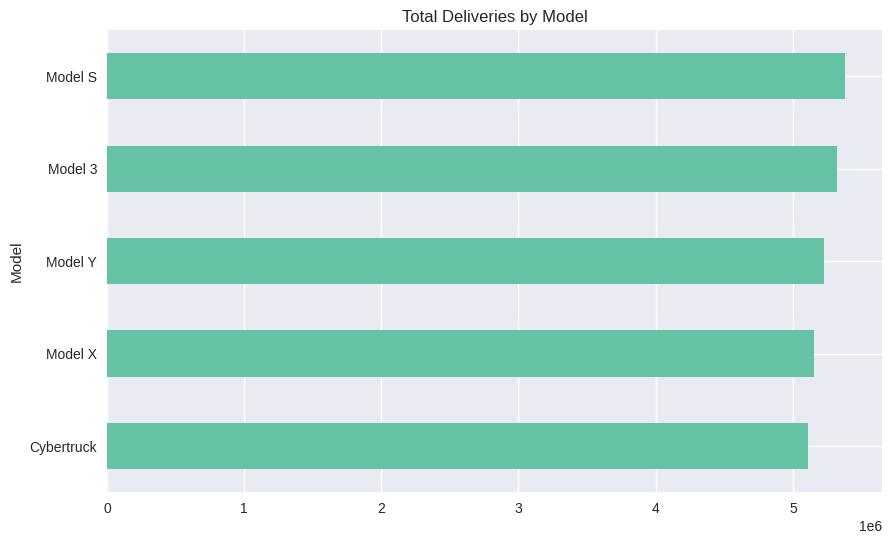

In [16]:
#Deliveries by Model ----
model_data = df.groupby("Model")["Estimated_Deliveries"].sum().sort_values()

plt.figure(figsize=(10,6))
model_data.plot(kind="barh")
plt.title("Total Deliveries by Model")
plt.show()

In [17]:
# EDA done above
# Feature Engineering starting
# Extracting time features

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter

# Drop Date (not needed directly)
df_model = df.copy()

df_model.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter
872,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01,1
2354,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,1
2312,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,1
2293,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01,1
2215,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01,1


In [18]:
#encoding categorial variables ---
df_model = pd.get_dummies(df_model, columns=["Region", "Model", "Source_Type"], drop_first=True)

df_model.head()


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Date,Quarter,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
872,2015,1,12446,13885,55183.13,60,340,634.75,4390,2015-01-01,1,False,False,False,False,False,False,True,False,True
2354,2015,1,11446,12752,89289.40,100,588,1009.54,8925,2015-01-01,1,False,True,False,True,False,False,False,False,False
2312,2015,1,8803,9344,102888.58,60,336,443.67,3923,2015-01-01,1,False,True,False,False,False,False,False,True,False
2293,2015,1,6367,6802,104962.32,82,459,438.37,9170,2015-01-01,1,False,False,True,False,False,False,False,False,False
2215,2015,1,8795,9165,87988.73,82,456,601.58,12626,2015-01-01,1,False,False,False,True,False,False,False,False,True


In [19]:
# defining x and y --

X = df_model.drop(["Estimated_Deliveries", "Date"], axis=1)
y = df_model["Estimated_Deliveries"]

print("Feature shape:", X.shape)

Feature shape: (2640, 18)


In [20]:
#train test ---

split_date = "2023-01-01"

X_train = X[df["Date"] < split_date]
X_test  = X[df["Date"] >= split_date]

y_train = y[df["Date"] < split_date]
y_test  = y[df["Date"] >= split_date]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1920, 18)
Test size: (720, 18)


In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 313.5775208333333
RMSE: 391.55594512900456
R2 Score: 0.9887100693239844


In [22]:
#creating lag features --- (beacuse r2 score is high)
df_lag = df.copy()

df_lag = df_lag.sort_values("Date")

df_lag["lag_1"] = df_lag["Estimated_Deliveries"].shift(1)
df_lag["lag_3"] = df_lag["Estimated_Deliveries"].shift(3)
df_lag["rolling_mean_3"] = df_lag["Estimated_Deliveries"].rolling(3).mean()

df_lag = df_lag.dropna()

df_lag.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,lag_1,lag_3,rolling_mean_3
1761,2015,1,North America,Model Y,12170,12958,70386.04,120,696,1270.55,Official (Quarter),4673,2015-01-01,1,10835.0,12446.0,11117.666667
1423,2015,1,Europe,Model 3,7597,8376,80810.67,75,417,475.19,Interpolated (Month),8942,2015-01-01,1,12170.0,10348.0,10200.666667
1478,2015,1,Middle East,Model X,7419,8000,79927.87,75,413,459.61,Official (Quarter),4294,2015-01-01,1,7597.0,10835.0,9062.000000
1597,2015,1,Asia,Model S,9537,10093,68994.43,82,484,692.39,Official (Quarter),7281,2015-01-01,1,7419.0,12170.0,8184.333333
1613,2015,1,Asia,Cybertruck,11325,11887,54449.08,60,339,575.88,Estimated (Region),6902,2015-01-01,1,9537.0,7597.0,9427.000000


In [23]:
df_lag = pd.get_dummies(df_lag, columns=["Region", "Model", "Source_Type"], drop_first=True)

X = df_lag.drop(["Estimated_Deliveries", "Date"], axis=1)
y = df_lag["Estimated_Deliveries"]


In [24]:
split_date = "2023-01-01"

X_train = X[df_lag["Date"] < split_date]
X_test  = X[df_lag["Date"] >= split_date]

y_train = y[df_lag["Date"] < split_date]
y_test  = y[df_lag["Date"] >= split_date]

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 325.87404166666664
RMSE: 404.6644752454735
R2 Score: 0.9879414860338299


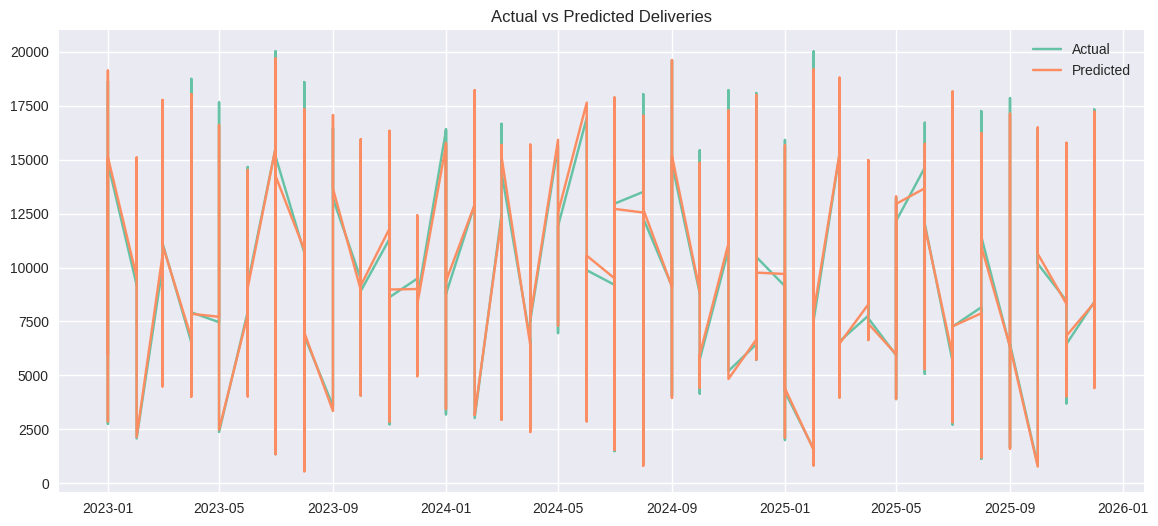

In [26]:
# actual vs predicted ---
results = pd.DataFrame({
    "Date": df_lag[df_lag["Date"] >= split_date]["Date"],
    "Actual": y_test,
    "Predicted": y_pred
})

results = results.sort_values("Date")

plt.figure(figsize=(14,6))
plt.plot(results["Date"], results["Actual"], label="Actual")
plt.plot(results["Date"], results["Predicted"], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Deliveries")
plt.show()

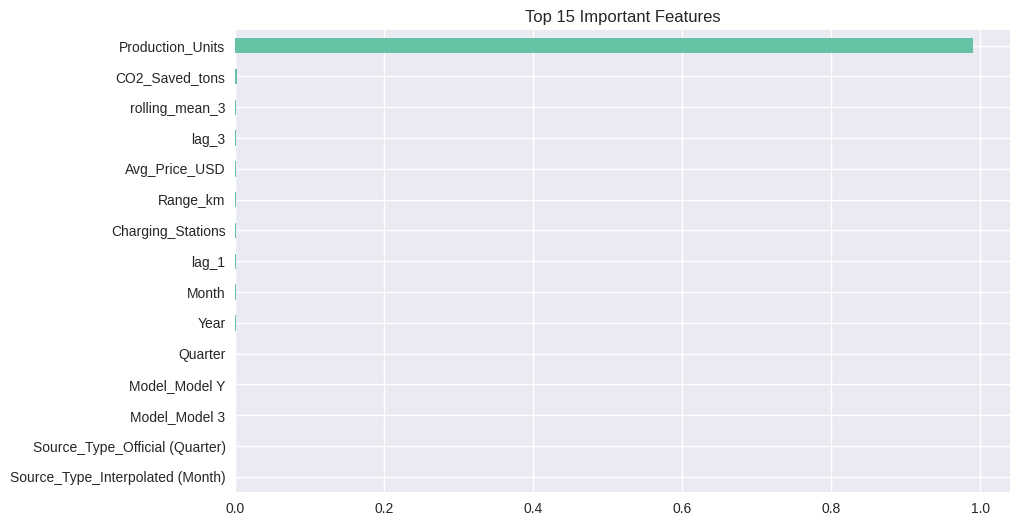

In [27]:
#feature importance ---
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.head(15).plot(kind="barh")
plt.title("Top 15 Important Features")
plt.gca().invert_yaxis()
plt.show()

In [28]:
X = df_lag.drop([
    "Estimated_Deliveries",
    "Date",
    "Production_Units",
    "CO2_Saved_tons"
], axis=1)

y = df_lag["Estimated_Deliveries"]

In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 325.87404166666664
RMSE: 404.6644752454735
R2 Score: 0.9879414860338299


In [30]:
#redefining X and Y ---
X = df_lag.drop([
    "Estimated_Deliveries",
    "Date",
    "Production_Units",
    "CO2_Saved_tons"
], axis=1)

y = df_lag["Estimated_Deliveries"]

print("Columns being used:")
print(X.columns)

Columns being used:
Index(['Year', 'Month', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'Charging_Stations', 'Quarter', 'lag_1', 'lag_3', 'rolling_mean_3',
       'Region_Europe', 'Region_Middle East', 'Region_North America',
       'Model_Model 3', 'Model_Model S', 'Model_Model X', 'Model_Model Y',
       'Source_Type_Interpolated (Month)', 'Source_Type_Official (Quarter)'],
      dtype='object')


In [31]:
split_date = "2023-01-01"

X_train = X[df_lag["Date"] < split_date]
X_test  = X[df_lag["Date"] >= split_date]

y_train = y[df_lag["Date"] < split_date]
y_test  = y[df_lag["Date"] >= split_date]

In [32]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2319.8050555555556
RMSE: 2836.5273037322
R2 Score: 0.40751471712265963


In [33]:
df_lag["lag_6"] = df_lag["Estimated_Deliveries"].shift(6)
df_lag["lag_12"] = df_lag["Estimated_Deliveries"].shift(12)
df_lag["rolling_mean_6"] = df_lag["Estimated_Deliveries"].rolling(6).mean()
df_lag["rolling_std_3"] = df_lag["Estimated_Deliveries"].rolling(3).std()

df_lag = df_lag.dropna()


In [34]:
df_lag["Month_sin"] = np.sin(2 * np.pi * df_lag["Month"] / 12)
df_lag["Month_cos"] = np.cos(2 * np.pi * df_lag["Month"] / 12)


In [35]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2336.73828125
RMSE: 2890.4667443165645
R2 Score: 0.38476699590682983


In [37]:
# Adding longer memory
df_lag["lag_6"] = df_lag["Estimated_Deliveries"].shift(6)
df_lag["lag_12"] = df_lag["Estimated_Deliveries"].shift(12)

df_lag["rolling_mean_6"] = df_lag["Estimated_Deliveries"].rolling(6).mean()
df_lag["rolling_mean_12"] = df_lag["Estimated_Deliveries"].rolling(12).mean()

df_lag["rolling_std_6"] = df_lag["Estimated_Deliveries"].rolling(6).std()

df_lag = df_lag.dropna()

In [38]:
df_lag["Month_sin"] = np.sin(2 * np.pi * df_lag["Month"] / 12)
df_lag["Month_cos"] = np.cos(2 * np.pi * df_lag["Month"] / 12)

df_lag = df_lag.drop("Month", axis=1)

In [39]:
X = df_lag.drop([
    "Estimated_Deliveries",
    "Date",
    "Production_Units",
    "CO2_Saved_tons"
], axis=1)

y = df_lag["Estimated_Deliveries"]

In [40]:
split_date = "2023-01-01"

X_train = X[df_lag["Date"] < split_date]
X_test  = X[df_lag["Date"] >= split_date]

y_train = y[df_lag["Date"] < split_date]
y_test  = y[df_lag["Date"] >= split_date]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1893, 26)
Test shape: (720, 26)


In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2212.72225
RMSE: 2769.3945320667426
R2 Score: 0.4352278259005812


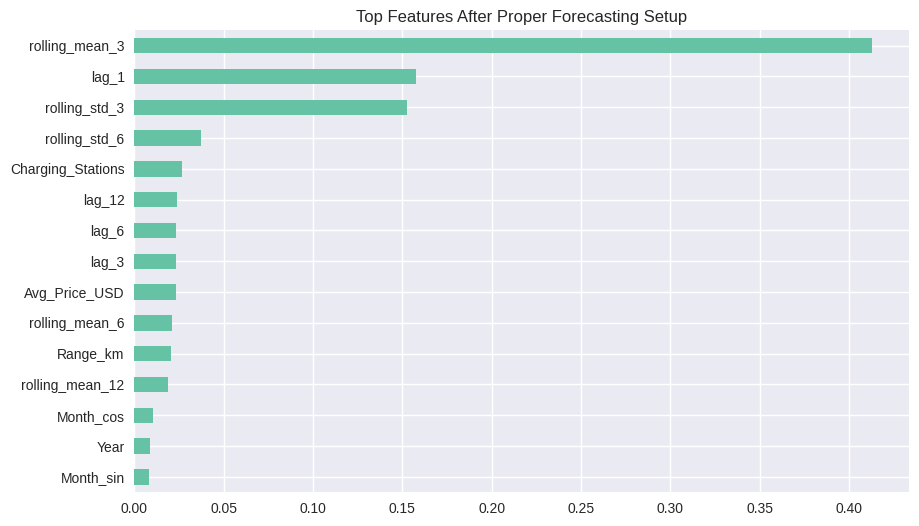

In [42]:
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top Features After Proper Forecasting Setup")
plt.show()

In [43]:
#regression modelling done here
#hyperparameter tuning is starting now --

In [44]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [45]:
tscv = TimeSeriesSplit(n_splits=5)

In [46]:
param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [47]:
rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

In [48]:
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV R2 Score:", grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R2 Score: 0.46294846454313393


In [49]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Final MAE:", mae)
print("Final RMSE:", rmse)
print("Final R2 Score:", r2)

Final MAE: 2264.5716746002586
Final RMSE: 2779.729883186826
Final R2 Score: 0.4310045123299493


In [50]:
#hyperparameter  tuning done here


In [51]:
forecast_df = df_lag.copy()

last_date = forecast_df["Date"].max()
print("Last available date:", last_date)

Last available date: 2025-12-01 00:00:00


In [52]:
future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

future_dates

DatetimeIndex(['2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01',
               '2026-05-01', '2026-06-01', '2026-07-01', '2026-08-01',
               '2026-09-01', '2026-10-01', '2026-11-01', '2026-12-01'],
              dtype='datetime64[ns]', freq='MS')

In [53]:
future_predictions = []

for future_date in future_dates:
    
    new_row = forecast_df.iloc[-1:].copy()
    new_row["Date"] = future_date
    
    new_row["Year"] = future_date.year
    month = future_date.month
    
    new_row["Month_sin"] = np.sin(2 * np.pi * month / 12)
    new_row["Month_cos"] = np.cos(2 * np.pi * month / 12)
    
    new_row["lag_1"] = forecast_df["Estimated_Deliveries"].iloc[-1]
    new_row["lag_3"] = forecast_df["Estimated_Deliveries"].iloc[-3]
    new_row["lag_6"] = forecast_df["Estimated_Deliveries"].iloc[-6]
    new_row["lag_12"] = forecast_df["Estimated_Deliveries"].iloc[-12]
    
    new_row["rolling_mean_3"] = forecast_df["Estimated_Deliveries"].iloc[-3:].mean()
    new_row["rolling_mean_6"] = forecast_df["Estimated_Deliveries"].iloc[-6:].mean()
    new_row["rolling_mean_12"] = forecast_df["Estimated_Deliveries"].iloc[-12:].mean()
    
    new_row["rolling_std_3"] = forecast_df["Estimated_Deliveries"].iloc[-3:].std()
    new_row["rolling_std_6"] = forecast_df["Estimated_Deliveries"].iloc[-6:].std()
    
    X_future = new_row.drop([
        "Estimated_Deliveries",
        "Date",
        "Production_Units",
        "CO2_Saved_tons"
    ], axis=1)
    
    future_pred = best_model.predict(X_future)[0]
    
    new_row["Estimated_Deliveries"] = future_pred
    future_predictions.append((future_date, future_pred))
    
    forecast_df = pd.concat([forecast_df, new_row], ignore_index=True)

In [54]:
forecast_results = pd.DataFrame(
    future_predictions,
    columns=["Date", "Forecasted_Deliveries"]
)

forecast_results

,Date,Forecasted_Deliveries
0,2026-01-01,10048.818451
1,2026-02-01,9664.993082
2,2026-03-01,9809.550412
3,2026-04-01,9850.147227
4,2026-05-01,9802.168298
5,2026-06-01,9833.375312
6,2026-07-01,9833.375312
7,2026-08-01,9833.375312
8,2026-09-01,9833.375312
9,2026-10-01,9833.375312


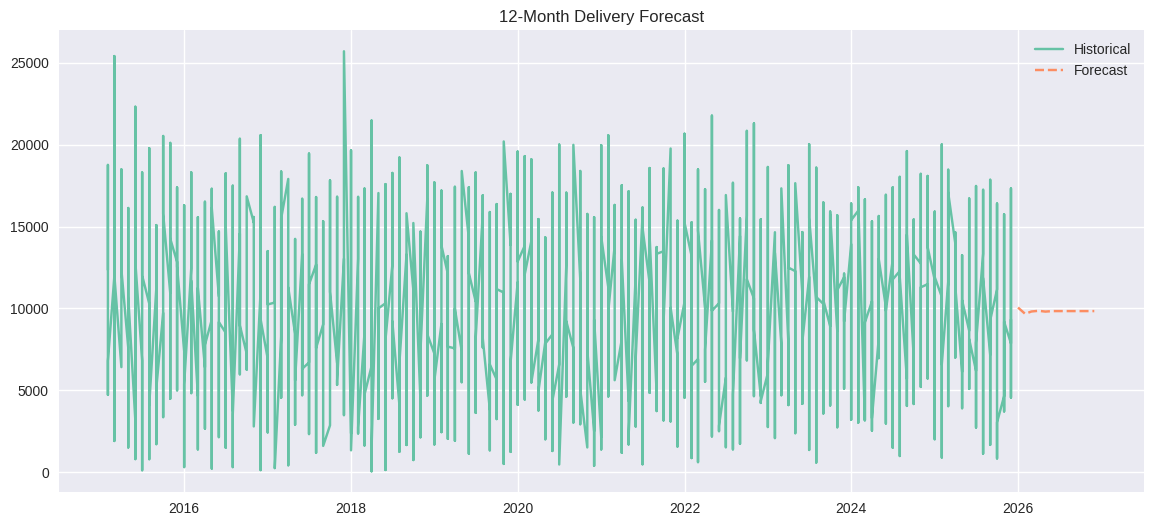

In [55]:
plt.figure(figsize=(14,6))

plt.plot(df_lag["Date"], df_lag["Estimated_Deliveries"], label="Historical")

plt.plot(forecast_results["Date"],
         forecast_results["Forecasted_Deliveries"],
         label="Forecast",
         linestyle="--")

plt.legend()
plt.title("12-Month Delivery Forecast")
plt.show()